# 00 — Data Time Fix

The robot crashed mid-run and restarted several times, producing multiple sub-folders per run with overlapping timestamps.

**Strategy:**
- Take all data from every sub-folder in full.
- Compute segment-boundary shifts from a reference sensor (accelerometer).
- Apply the same boundary shifts to all sensors to preserve cross-sensor alignment.
- Insert a small intra-segment time gap to avoid duplicate boundary timestamps.
- Shift each next run by `RUN_GAP_SECONDS` (120 s) after the previous run ends.
- Keep the `%`-comment header from the first sub-folder only.
- Write merged files directly into `data/raw/Farm/RunX/`.

**It is not part of the pipeline** — only run this notebook to fix overlapping-timestamp issues from robot crashes.

In [1]:
from pathlib import Path
import numpy as np

In [ ]:
# -- Configuration ------------------------------------------------------------
DATA_ROOT    = Path("/Users/pratyush/aaa/28_apr")

SENSOR_FILES = [
    "log_t0_acc_1.txt",
    "log_t0_encoder_velocity.txt",
    "log_t0_gyro_1.txt",
    "log_t0_pose.txt",
]
RUN_GAP_SECONDS = 120.0

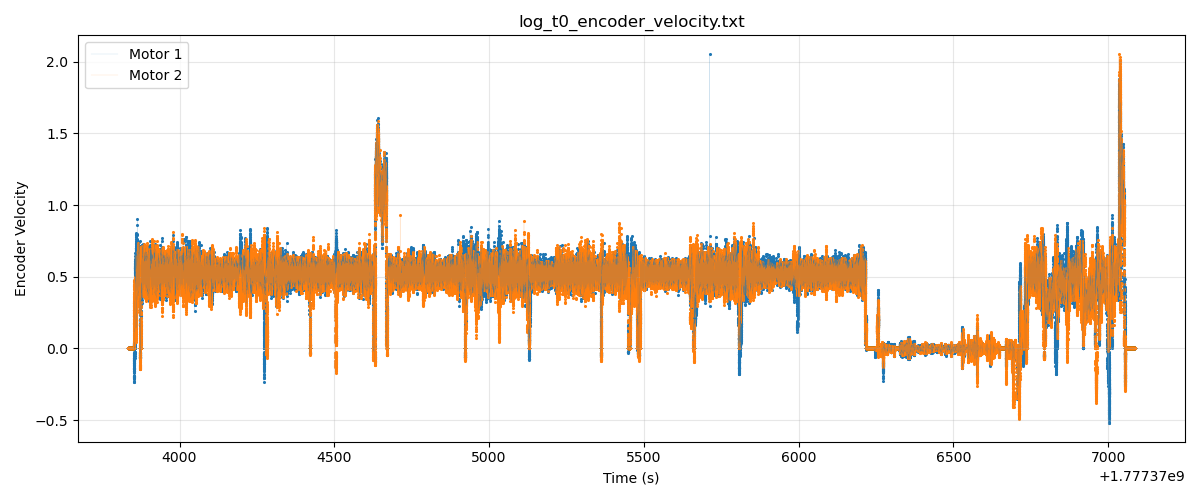

In [7]:
%matplotlib widget
import matplotlib.pyplot as plt
import mplcursors

# Find the encoder file anywhere under DATA_ROOT so the cell works for both a single run folder
# and a root directory that contains Run*/ or log_* subfolders.
encoder_matches = sorted(DATA_ROOT.rglob("log_t0_encoder_velocity.txt"))
if not encoder_matches:
    raise FileNotFoundError(f"Could not find log_t0_encoder_velocity.txt under {DATA_ROOT}")
encoder_file = encoder_matches[0]

times = []
velocity_1 = []
velocity_2 = []
with open(encoder_file) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("%"):
            continue
        parts = line.split()
        if len(parts) < 3:
            continue
        times.append(float(parts[0]))
        velocity_1.append(float(parts[1]))
        velocity_2.append(float(parts[2]))

# Plot both velocity channels with clickable point labels.
fig, ax = plt.subplots(figsize=(12, 5))
line_1, = ax.plot(times, velocity_1, linewidth=0.1, alpha=0.75, label="Motor 1")
line_2, = ax.plot(times, velocity_2, linewidth=0.1, alpha=0.75, label="Motor 2")
points_1 = ax.scatter(times, velocity_1, s=1.5, color=line_1.get_color())
points_2 = ax.scatter(times, velocity_2, s=1.5, color=line_2.get_color())
ax.set_xlabel("Time (s)")
ax.set_ylabel("Encoder Velocity")
ax.set_title(str(encoder_file.relative_to(DATA_ROOT)))
ax.legend()
ax.grid(True, alpha=0.3)

cursor = mplcursors.cursor([points_1, points_2], hover=False)
series_labels = {points_1: "Motor 1", points_2: "Motor 2"}

@cursor.connect("add")
def on_add(sel):
    idx = sel.index
    series_name = series_labels.get(sel.artist, "Velocity")
    value = velocity_1[idx] if sel.artist is points_1 else velocity_2[idx]
    sel.annotation.set_text(f"{series_name}\nt = {times[idx]:.4f} s\nv = {value:.4f}")
    sel.annotation.get_bbox_patch().set(alpha=0.85)

plt.tight_layout()
plt.show()

In [12]:
def read_sensor_file(filepath):
    """Return (header_lines, data) where data is an (N, C) float64 array."""
    header, rows = [], []
    with open(filepath, errors="replace") as f:
        for line in f:
            line = line.replace("\x00", "").rstrip("\n")
            if not line.strip():
                continue
            if line.startswith("%"):
                header.append(line)
                continue
            parts = line.split()
            if not parts:
                continue
            rows.append([float(x) for x in parts])
    return header, np.array(rows, dtype=float)


def write_sensor_file(filepath, header_lines, data):
    """Write header comments followed by space-separated data rows."""
    with open(filepath, "w") as f:
        for h in header_lines:
            f.write(h + "\n")
        for row in data:
            parts = [f"{v:.4f}" for v in row]
            f.write(" ".join(parts) + "\n")


def clip_segments_to_common_end(sensor_segments, sensor_files):
    """Clip each sub-folder's segments to the earliest end time across all sensors.

    After a robot crash some sensors keep recording longer than others.
    Clipping to the minimum end time removes this post-crash tail so that
    all sensors share the same segment boundaries before shifts are applied.
    """
    n_segs = len(sensor_segments[sensor_files[0]])
    for i in range(n_segs):
        t_end = min(sensor_segments[sf][i][-1, 0] for sf in sensor_files)
        for sf in sensor_files:
            seg = sensor_segments[sf][i]
            sensor_segments[sf][i] = seg[seg[:, 0] <= t_end]
    return sensor_segments


def compute_segment_shifts(reference_segments, intra_gap_seconds=0.01):
    """Compute per-segment timestamp shifts from one reference sensor."""
    shifts = [0.0]
    current_end = float(reference_segments[0][-1, 0])

    for seg in reference_segments[1:]:
        seg_start = float(seg[0, 0])
        shift = (current_end + intra_gap_seconds) - seg_start
        shifts.append(shift)
        current_end = float(seg[-1, 0] + shift)

    return shifts


def apply_shifts(segments, shifts):
    """Apply precomputed shifts to all segments of a sensor."""
    out = []
    for seg, shift in zip(segments, shifts):
        shifted = seg.copy()
        shifted[:, 0] += shift
        out.append(shifted)
    return out


def process_run(
    run_dir,
    sensor_files,
    prev_run_end=None,
    run_gap_seconds=120.0,
    reference_sensor="log_t0_acc_1.txt",
    intra_gap_seconds=0.01,
):
    """Merge all sub-folder segments per sensor with shared boundary and run shifts.

    Returns: end timestamp of this run for spacing the next run.
    """
    subfolders_all = sorted([d for d in run_dir.iterdir() if d.is_dir()])
    if not subfolders_all:
        print(f"  [SKIP] No sub-folders found in {run_dir.name}")
        return prev_run_end

    subfolders = []
    for d in subfolders_all:
        if all((d / sf).exists() for sf in sensor_files):
            subfolders.append(d)
        else:
            print(f"  [WARN] Skipping incomplete segment folder: {d.name}")

    if not subfolders:
        print(f"  [SKIP] No complete sub-folders found in {run_dir.name}")
        return prev_run_end

    print(f"  Sub-folders ({len(subfolders)}): {[d.name for d in subfolders]}")

    sensor_segments = {}
    sensor_headers = {}
    for sensor_file in sensor_files:
        segments = []
        header_lines = None
        print(f"\n  {sensor_file}")
        for folder in subfolders:
            fp = folder / sensor_file
            header, data = read_sensor_file(fp)
            if header_lines is None:
                header_lines = header
            segments.append(data)
            print(f"    {folder.name}: {len(data):>6} rows  t=[{data[0,0]:.4f} .. {data[-1,0]:.4f}]")
        sensor_segments[sensor_file] = segments
        sensor_headers[sensor_file] = header_lines if header_lines is not None else []

    if reference_sensor not in sensor_segments:
        raise ValueError(f"Reference sensor not found: {reference_sensor}")

    # Clip each sub-folder to the minimum end time across all sensors.
    # This removes post-crash tails where one sensor kept recording after
    # the others stopped, which would otherwise create overlap or gaps when
    # the same ACC-based shifts are applied to all sensors.
    sensor_segments = clip_segments_to_common_end(sensor_segments, sensor_files)

    # Compute boundary shifts from the reference sensor (accelerometer) only,
    # then apply the same shifts to all sensors to preserve cross-sensor alignment.
    boundary_shifts = compute_segment_shifts(
        sensor_segments[reference_sensor],
        intra_gap_seconds=intra_gap_seconds,
    )
    for sensor_file in sensor_files:
        sensor_segments[sensor_file] = apply_shifts(sensor_segments[sensor_file], boundary_shifts)

    run_shift = 0.0
    if prev_run_end is not None:
        current_run_start = float(sensor_segments[reference_sensor][0][0, 0])
        run_shift = (float(prev_run_end) + float(run_gap_seconds)) - current_run_start
        for sensor_file in sensor_files:
            for seg in sensor_segments[sensor_file]:
                seg[:, 0] += run_shift
        print(f"\n  Applied run-level shift: {run_shift:+.4f}s")

    run_end_times = []
    for sensor_file in sensor_files:
        merged = np.vstack(sensor_segments[sensor_file])
        out_path = run_dir / sensor_file
        write_sensor_file(out_path, sensor_headers[sensor_file], merged)
        run_end_times.append(float(merged[-1, 0]))
        print(f"  -> saved {sensor_file}: rows={len(merged)}, t=[{merged[0,0]:.4f} .. {merged[-1,0]:.4f}]")

    return max(run_end_times) if run_end_times else prev_run_end

In [13]:
# -- Optional: import external single-collection and split into sub-folders --
# Set this to a folder containing the raw sensor files (one collection).
# If you want to split that single continuous capture into multiple sub-folders
# (segments) provide unix timestamps in `SPLIT_UNIX_TIMES`. Leave empty to skip.
EXTERNAL_INPUT = Path("/Users/pratyush/aaa/28_apr")
# Example: [1680000000.0, 1680000720.0] — unix times where runs separate (ascending).
SPLIT_UNIX_TIMES = [1777374667, 1777375499]  # <-- edit this list with exact split times later


def find_next_run_name(data_root, base_name="Run"):
    runs = sorted([d for d in data_root.iterdir() if d.is_dir() and d.name.startswith(base_name)])
    nums = [int(d.name[len(base_name):]) for d in runs if d.name[len(base_name):].isdigit()]
    next_num = max(nums) + 1 if nums else 3
    next_num = max(next_num, 3)  # Never reuse Run1 or Run2; those are reserved.
    while (data_root / f"{base_name}{next_num}").exists():
        next_num += 1
    return f"{base_name}{next_num}"


def split_input_into_subfolders(input_dir, out_run_dir, sensor_files, split_unix_times):
    """Split each sensor file into segment sub-folders by unix time boundaries."""
    out_run_dir.mkdir(parents=True, exist_ok=True)
    times = sorted(split_unix_times)
    boundaries = [-float("inf")] + times + [float("inf")]
    for i in range(len(boundaries) - 1):
        seg_dir = out_run_dir / f"seg{i+1:02d}"
        seg_dir.mkdir(exist_ok=True)
        t_min, t_max = boundaries[i], boundaries[i+1]
        for sf in sensor_files:
            in_fp = input_dir / sf
            if not in_fp.exists():
                print(f"  [WARN] Missing sensor file {in_fp}")
                continue
            header, data = read_sensor_file(in_fp)
            if data.size == 0:
                # nothing to write except header
                write_sensor_file(seg_dir / sf, header if header is not None else [], np.empty((0, 1)))
                print(f"  {sf}: 0 rows for segment {i+1}")
                continue
            mask = (data[:, 0] > t_min) & (data[:, 0] <= t_max)
            seg_data = data[mask]
            if seg_data.size == 0:
                write_sensor_file(seg_dir / sf, header if header is not None else [], np.empty((0, data.shape[1])))
                print(f"  {sf}: 0 rows for segment {i+1}")
            else:
                write_sensor_file(seg_dir / sf, header if header is not None else [], seg_data)
                print(f"  {sf}: {len(seg_data)} rows -> {seg_dir / sf}")
    print(f"Created run folder: {out_run_dir}")


# If the external folder exists and split times provided, create a new Run under DATA_ROOT
if EXTERNAL_INPUT.exists() and EXTERNAL_INPUT.is_dir() and SPLIT_UNIX_TIMES:
    new_run_name = find_next_run_name(DATA_ROOT, base_name="Run")
    out_run = DATA_ROOT / new_run_name
    print(f"Preparing run {out_run} from {EXTERNAL_INPUT} with splits={SPLIT_UNIX_TIMES}")
    try:
        split_input_into_subfolders(EXTERNAL_INPUT, out_run, SENSOR_FILES, SPLIT_UNIX_TIMES)
    except ValueError as e:
        print(f"[ERROR] Failed to split input: {e}")
        print("This may be due to corrupted sensor files (e.g., containing null bytes).")
        print("Please verify the sensor files in:", EXTERNAL_INPUT)
    else:
        print("External input split complete. The new run will be picked up by the processing loop.")
elif EXTERNAL_INPUT.exists() and EXTERNAL_INPUT.is_dir():
    print("External input found but no split times provided — skip splitting.")
    print("Set SPLIT_UNIX_TIMES to a list of unix timestamps to enable splitting.")
else:
    print("No external input configured or path does not exist.")


Preparing run /Users/pratyush/aaa/28_apr/Run3 from /Users/pratyush/aaa/28_apr with splits=[1777374667, 1777375499]
  log_t0_acc_1.txt: 69370 rows -> /Users/pratyush/aaa/28_apr/Run3/seg01/log_t0_acc_1.txt
  log_t0_encoder_velocity.txt: 69370 rows -> /Users/pratyush/aaa/28_apr/Run3/seg01/log_t0_encoder_velocity.txt
  log_t0_gyro_1.txt: 69370 rows -> /Users/pratyush/aaa/28_apr/Run3/seg01/log_t0_gyro_1.txt
  log_t0_pose.txt: 118918 rows -> /Users/pratyush/aaa/28_apr/Run3/seg01/log_t0_pose.txt
  log_t0_acc_1.txt: 69333 rows -> /Users/pratyush/aaa/28_apr/Run3/seg02/log_t0_acc_1.txt
  log_t0_encoder_velocity.txt: 69333 rows -> /Users/pratyush/aaa/28_apr/Run3/seg02/log_t0_encoder_velocity.txt
  log_t0_gyro_1.txt: 69333 rows -> /Users/pratyush/aaa/28_apr/Run3/seg02/log_t0_gyro_1.txt
  log_t0_pose.txt: 118856 rows -> /Users/pratyush/aaa/28_apr/Run3/seg02/log_t0_pose.txt
  log_t0_acc_1.txt: 132192 rows -> /Users/pratyush/aaa/28_apr/Run3/seg03/log_t0_acc_1.txt
  log_t0_encoder_velocity.txt: 132193

In [4]:
# -- Process all runs ----------------------------------------------------------
runs = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir() and d.name.startswith("Run")])
print(f"Runs found: {[r.name for r in runs]}\n")

prev_run_end = None
for run_dir in runs:
    print("=" * 60)
    print(f"Processing {run_dir.name} ...")
    prev_run_end = process_run(
        run_dir,
        SENSOR_FILES,
        prev_run_end=prev_run_end,
        run_gap_seconds=RUN_GAP_SECONDS,
        reference_sensor="log_t0_acc_1.txt",
        intra_gap_seconds=0.01,
    )

print("\n" + "=" * 60)
print("Done.")

Runs found: ['Run1', 'Run2']

Processing Run1 ...
  Sub-folders (3): ['log_20260421_114126.191', 'log_20260421_114126.852', 'log_20260421_114127.477']

  log_t0_acc_1.txt
    log_20260421_114126.191:   5807 rows  t=[1776764504.9092 .. 1776764574.5822]
    log_20260421_114126.852:  13524 rows  t=[1776764505.4699 .. 1776764667.8892]
    log_20260421_114127.477:  24663 rows  t=[1776764506.2748 .. 1776764802.2628]

  log_t0_encoder_velocity.txt
    log_20260421_114126.191:   5727 rows  t=[1776764504.9063 .. 1776764573.6187]
    log_20260421_114126.852:  13101 rows  t=[1776764505.4685 .. 1776764662.8009]
    log_20260421_114127.477:  24666 rows  t=[1776764506.2731 .. 1776764802.2953]

  log_t0_gyro_1.txt
    log_20260421_114126.191:   7863 rows  t=[1776764504.9090 .. 1776764599.2812]
    log_20260421_114126.852:  14443 rows  t=[1776764505.4687 .. 1776764678.9048]
    log_20260421_114127.477:  24719 rows  t=[1776764506.2744 .. 1776764802.9341]

  log_t0_pose.txt
    log_20260421_114126.191: 

In [5]:
# ── Verification ──────────────────────────────────────────────────────────────
print("Merged file summary\n" + "─" * 60)

for run_dir in runs:
    print(f"\n{run_dir.name}:")
    for sensor_file in SENSOR_FILES:
        out_path = run_dir / sensor_file
        if not out_path.exists():
            print(f"  {sensor_file}: NOT FOUND")
            continue
        _, data = read_sensor_file(out_path)
        nan_mask = np.isnan(data[:, 1])
        boundary_times = data[nan_mask, 0]
        print(f"  {sensor_file}:")
        print(f"    rows={len(data)}, boundaries={nan_mask.sum()}, "
              f"t_start={data[0,0]:.4f}, t_end={data[-1,0]:.4f}")
        for b_t in boundary_times:
            idx = int(np.where(data[:, 0] == b_t)[0][0])
            t_before = data[idx - 1, 0] if idx > 0 else float("nan")
            t_after  = data[idx + 1, 0] if idx < len(data) - 1 else float("nan")
            print(f"    boundary @ t={b_t:.4f}  "
                  f"prev={t_before:.4f}  next={t_after:.4f}  "
                  f"gap={t_after - t_before:.3f}s")

Merged file summary
────────────────────────────────────────────────────────────

Run1:
  log_t0_acc_1.txt:
    rows=43488, boundaries=0, t_start=1776764504.9092, t_end=1776765026.9367
  log_t0_encoder_velocity.txt:
    rows=43491, boundaries=0, t_start=1776764504.9063, t_end=1776765026.9331
  log_t0_gyro_1.txt:
    rows=43490, boundaries=0, t_start=1776764504.9090, t_end=1776765026.9367
  log_t0_pose.txt:
    rows=74547, boundaries=0, t_start=1776764504.9060, t_end=1776765026.9330

Run2:
  log_t0_acc_1.txt:
    rows=75007, boundaries=0, t_start=1776765146.9367, t_end=1776766047.2442
  log_t0_encoder_velocity.txt:
    rows=75014, boundaries=0, t_start=1776765146.9349, t_end=1776766047.2555
  log_t0_gyro_1.txt:
    rows=75009, boundaries=0, t_start=1776765146.9363, t_end=1776766047.2555
  log_t0_pose.txt:
    rows=128575, boundaries=0, t_start=1776765146.9334, t_end=1776766047.2543
